<h2>Data Analytics- notebook, Compost coders</h2>

<h4><b>Dataset name: Short description</b></h4>

Data analysis on Dynamic Modeling of Poultry Litter Composting in High Mountain Climates using System Identification Techniques

<h4><b>Data source (url):</b></h4>

https://data.mendeley.com/datasets/dgxxj2pk8s/2

<h4><b>Data format:</b></h4>

Describe file structure here.

<h4><b>Data description, features and limitations:</b></h4>

NOTE: AI has been used heavily in this notebook to help create code and analyse data

<h3 style="color: red"><b>Code: importing modules, custom functions and loading the data</b></h3>

In [297]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import openpyxl

In [298]:
# Load the dataset
df = pd.read_excel('../../data/compost_dataset_4.xlsx')

<h3 style="color: red"><b>Code: Data clean-up procedure</b></h3>

In [299]:
df.columns

Index(['Hour', 'Minutes', 'Temp. Heater', 'Temp. Biopila', 'Humidity',
       'Input_Air', 'Entrada Heat', 'Days', 'Unnamed: 8'],
      dtype='str')

In [300]:
# Example: define a starting date
start_date = pd.Timestamp("2026-01-01")

df["timestamp"] = (
    start_date
    + pd.to_timedelta(df["Days"], unit="D")
    + pd.to_timedelta(df["Hour"], unit="h")
    + pd.to_timedelta(df["Minutes"], unit="m")
)
df = df.set_index("timestamp")
df = df.resample("1h").agg({
    "Temp. Heater": "mean",
    "Humidity": "mean",
    "Temp. Biopila": "mean"
}).reset_index()

# Select numeric columns, but exclude 'timestamp'
numeric_cols = df.select_dtypes(include="number").columns
numeric_cols = [col for col in numeric_cols if col != "timestamp"]

# Round numeric columns except timestamp to 2 decimal places
df[numeric_cols] = df[numeric_cols].round(2)
df.dropna(inplace=True)

# Fixes 2 column name rows
# df = df.resample("3min").mean(numeric_only=True)
# df = df.reset_index()

In [301]:
df

,timestamp,Temp. Heater,Humidity,Temp. Biopila
0,2026-01-02 00:00:00,41.36,81.14,27.02
1,2026-01-02 01:00:00,41.05,80.59,27.03
2,2026-01-02 02:00:00,40.28,80.63,27.04
3,2026-01-02 03:00:00,39.63,80.48,26.91
4,2026-01-02 04:00:00,38.88,80.58,26.87
...,...,...,...,...
355,2026-01-16 19:00:00,14.54,22.18,31.76
356,2026-01-16 20:00:00,13.65,22.04,31.62
357,2026-01-16 21:00:00,13.16,21.95,31.52
358,2026-01-16 22:00:00,13.08,22.08,31.27


In [302]:
# df.drop(columns=["Days", "Hour", "Minutes", "Entrada Heat"], inplace=True)

In [303]:
df.columns = df.columns.str.replace('Temp. Heater', 'incoming_heater_temp_C')
df.columns = df.columns.str.replace('Temp. Biopila', 'internal_compost_temp_C')

In [304]:
# Use the new total_hours column
selected_columns = ['timestamp', 'incoming_heater_temp_C', 'internal_compost_temp_C', 'Humidity']

# filter out the columns we want to see
filtered_df = df[selected_columns]

# Define start and end dates
start_date = '2026-01-01'
end_date   = '2026-01-16'

# Filter the data
filtered_df = filtered_df[(filtered_df['timestamp'] >= start_date) & (filtered_df['timestamp'] <= end_date)]

# switch to long format with melt, easier to visualize with multiline plots
# see the lecture example of ricebeefcoffee_revisited for another example!
df_long = pd.melt(
    filtered_df,
    id_vars=["timestamp"],
    var_name="Sensor",
    value_name="Value"
)

In [305]:
df

,timestamp,incoming_heater_temp_C,Humidity,internal_compost_temp_C
0,2026-01-02 00:00:00,41.36,81.14,27.02
1,2026-01-02 01:00:00,41.05,80.59,27.03
2,2026-01-02 02:00:00,40.28,80.63,27.04
3,2026-01-02 03:00:00,39.63,80.48,26.91
4,2026-01-02 04:00:00,38.88,80.58,26.87
...,...,...,...,...
355,2026-01-16 19:00:00,14.54,22.18,31.76
356,2026-01-16 20:00:00,13.65,22.04,31.62
357,2026-01-16 21:00:00,13.16,21.95,31.52
358,2026-01-16 22:00:00,13.08,22.08,31.27


In [306]:
df.isna().sum()

timestamp                  0
incoming_heater_temp_C     0
Humidity                   0
internal_compost_temp_C    0
dtype: int64

In [307]:
df = df[df['timestamp'] < '2026-01-09']

<h3 style="color: red"><b>Code: Data analysis</b></h3>

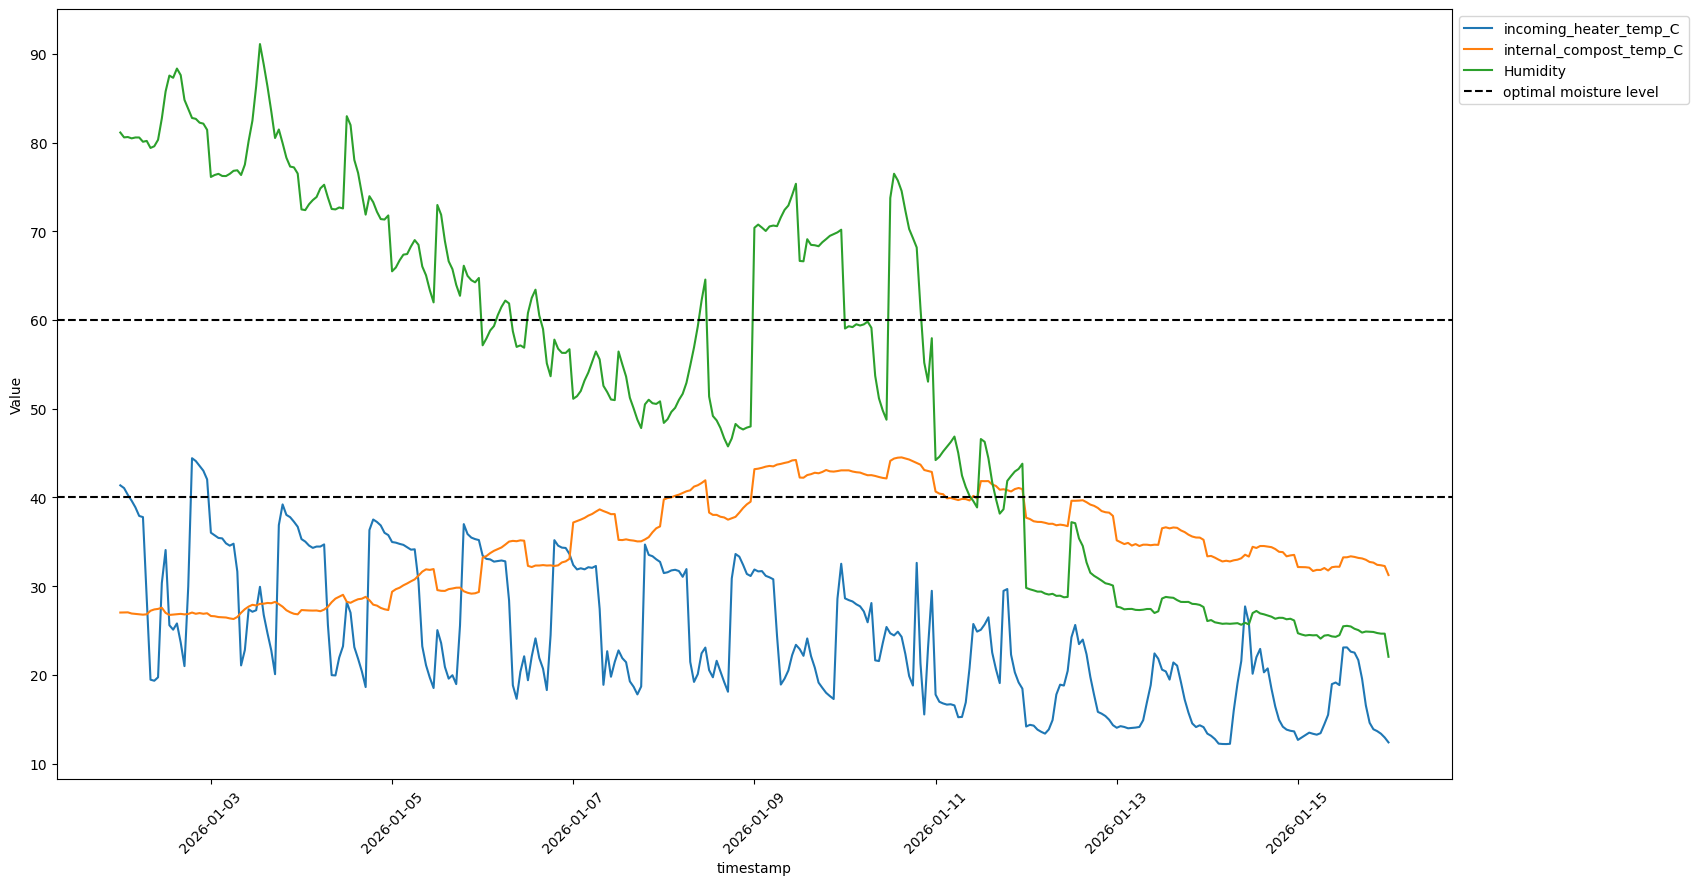

In [308]:
# increase the plot size, also place the legend outside the plot
# also rotate x-labels 45 degrees for easier readability
plt.figure(figsize=(18, 10))
plot = sns.lineplot(data=df_long, x="timestamp", y="Value", hue="Sensor", errorbar=None)
plt.xticks(rotation=45)
plt.axhline(y=40, color='black', linestyle='--', label='optimal moisture level')
plt.axhline(y=60, color='black', linestyle='--')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))

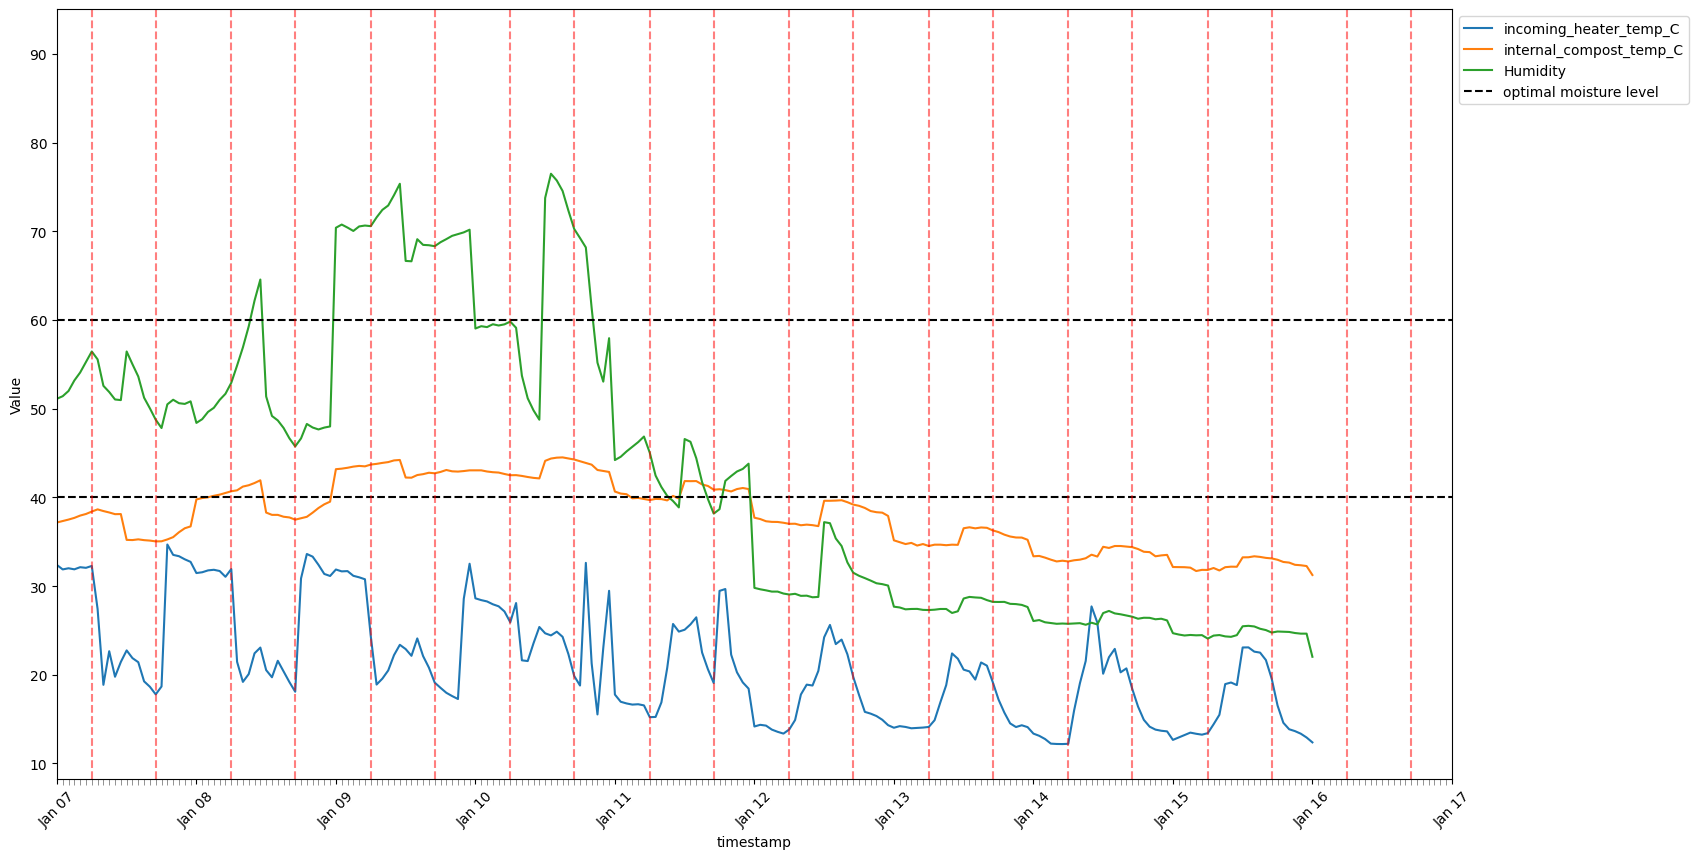

In [309]:
# Define start and end of range
start_ts = pd.Timestamp("2026-01-07 00:00")
end_ts   = pd.Timestamp("2026-01-17 00:00")

plt.figure(figsize=(18, 10))
plot = sns.lineplot(data=df_long, x="timestamp", y="Value", hue="Sensor", errorbar=None)

# Limit x-axis to desired range
plt.xlim(start_ts, end_ts)

# Rotate x-labels
plt.xticks(rotation=45)

# Horizontal lines
plt.axhline(y=40, color='black', linestyle='--', label='optimal moisture level')
plt.axhline(y=60, color='black', linestyle='--')

# Generate list of dates
all_days = pd.date_range(start=start_ts.floor('D'), end=end_ts.floor('D'), freq='D')

# Loop through each day and plot vertical lines at 7:00 and 19:00
for day in all_days:
    plt.axvline(x=day + pd.Timedelta(hours=6), color='red', linestyle='--', alpha=0.5)
    plt.axvline(x=day + pd.Timedelta(hours=17), color='red', linestyle='--', alpha=0.5)

# Place legend outside
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))

# -----------------------------
# Set x-axis ticks to show each hour
ax = plt.gca()  # get current axis

# Major ticks every 6 hours (optional)
ax.xaxis.set_major_locator(mdates.DayLocator())  # optional: one major tick per day
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))  # show day as label

# Minor ticks every hour
ax.xaxis.set_minor_locator(mdates.HourLocator(interval=1))
ax.tick_params(axis='x', which='minor', length=4, color='gray')  # tiny ticks

# Format the x-axis nicely (optional: rotate labels for minor ticks if needed)
plt.show()

<h3 style="color: red"><b>Results and summary:</b></h3>

<h3><strong>Overview</strong></h3>
This chart shows moisture, internal temperature and heater temperature levels.

<h3><strong>Key Observations</strong></h3>

<h4><strong>Material characteristics</strong></h4>
The reference dataset describes two controlled composting experiments using poultry litter as the primary material and forced aeration as the operational method. The material is rich in nitrogen and moisture, and the system is designed to study composting dynamics under high‑mountain climatic conditions. In contrast, the provided image reflects a smaller, non-forced-aeration system, but the same core variables - temperature, humidity, and heat input are directly comparable. The similarity in monitored parameters allows meaningful interpretation even though the material differs.

<h4><strong>Moisture distribution</strong></h4>
The humidity trend in the provided time‑series graph shows an initial level near 85-90%, gradually declining toward 50-60%. This pattern indicates that the compost mass begins very wet and slowly dries over time. In systems without forced aeration, moisture tends to migrate downward due to gravity, creating wetter lower layers and drier upper layers. Although the dataset page emphasizes controlled airflow and humidity monitoring in poultry-litter composting, the same principle applies here: uneven moisture distribution reduces uniform microbial activity.

<h4><strong>Temperature development</strong></h4>
The dataset page highlights that forced-aeration systems typically monitor both hot air temperature and compost pile temperature to maintain thermophilic conditions. In the analysed graph (seen above), internal compost temperatures remain in the mesophilic range (25-35 °C) and never reach the thermophilic zone typical of well‑aerated systems. 

Incoming heater temperature fluctuates between ~15–40 °C. The pattern indicates that the heater is not controleld by an automated feedback loop but instead follows a clock-based schedule. The heater appears to reduce output or switch off around 17:00 each day and resume heating at approximately 06:00. However, the exact start and stop times vary from day to day, suggesting that the system is manually controlled or adjusted rather than precisely automated. This results in the irregular but recurring temperature waves visible in the graph.

Simply put the heater it turned ON for the night and turned OFF for the day.

<h4><strong>Temperature–moisture relationship</strong></h4>
The temperature curve closely mirrors the moisture imbalance. Early in the process, when moisture is uniformly high, microbial activity is stronger. As the system dries unevenly, activity becomes localized, primarily in the wetter lower layers. This behavior aligns with the controlled experiments described in the dataset, where temperature, humidity, and airflow are tightly linked and monitored to understand composting dynamics. In both contexts, uneven moisture distribution leads to reduced heat generation and diminished composting efficiency.

<h4><strong>Overall interpretation</strong></h4>
The composting process shown in the image begins under favorable biological conditions but becomes increasingly limited by physical constraints. In comparison to the forced‑aeration poultry‑litter experiments, which maintain controlled airflow, heat input, and oxygen levels, the observed system lacks structural support and aeration. The main limiting factors are:

Absence of forced aeration, reducing oxygen availability

Moisture stratification, with wet lower layers and dry upper layers

Inconsistent heat input and poor heat retention

Localized microbial activity rather than uniform decomposition